**Claudi Vall Müller - University of Barcelona**


Last modified: 08/11/2024


## Functions

In [1]:
from scipy.integrate import quad
import numpy as np
from math import sin, cos, tan, radians, asin, acos, atan, pi
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt

# Numerical Constants
c = 299792458/1000  # km/s
H_0 = 70  # km/s / Mpc
O_m = 0.3


### Angular diameter distance calculator
def integrand(z, H_0, O_m):
    '''Integrand for the angular diameter distance integral.'''
    Hz = H_0 * (O_m * (1+z)**3 + (1-O_m))**0.5
    f = 1/Hz    
    return f

def D_A(z_1, z_2):
    '''Computes angular diameter distance from two different redshift points, z_2 > z_1. For example,
    z_1 = 0 (observer), z_2 = z_S for computing D_S.
    c is the speed of light in km/s, H0 is the hubble constant in km/s/Mpc and O_m is omega matter from the
    cosmological model. Angular diameter distance returned is in Mpc.'''
    
    integral = quad(integrand, z_1, z_2, args = (H_0, O_m))
    D = c/(1 + z_2) * np.array(integral)
    
    return D


# Kappa star computation
def kappa_star_comput(sigma_star, z_L, z_S):
    '''Computes k* = sigma*/sigma_crit. Arguments are sigma* (in M_sun/pc^2), redshift of the lens (z_l) and 
    redshift of the source (z_s). Returns k*.'''
    c = 299792458  # m/s
    G = 6.67430e-11 # N m^2 kg^-2
    
    M_sun = 1.98847e30 # kg 
    pc = 30856775814913673 # m
    
    D_S = D_A(0, z_S)
    D_L = D_A(0, z_L)
    D_LS = D_A(z_L, z_S)
    
    sigma_crit = c**2/(4*pi*G) * pc/M_sun * D_S/(D_L * D_LS) * 1e-6    # M_sun/pc^2
    kappa_star = sigma_star/sigma_crit
    
    return kappa_star

## Dictionaries

In [2]:
# Lens and source redshifts
lens_redshift = {1: 0.544, 2: 0.397, 3: 0.397, 4: 0.397, 5: 0.566, 6: 0.443, 7: 0.308, 8: 0.591, 9: 0.591, 10: 0.870, 11: 0.375, 12: 0.397}
source_redshift = {1: 1.49, 2: 1.0054, 3: 1.0054, 4: 0.9397, 5: 6.2, 6: 2.37, 7: 2.6501, 8: 4.8, 9: 4.8, 10: 2.1878, 11: 1.2567, 12: 2.091}

# Distance from images to MaCL from observations
theta_dict = {1: +0.13, 2: 'nan', 3: 'nan', 4: +0.06, 5: -0.009, 6: +0.55, 7: -0.15, 8: -0.1, 9: -0.32, 10: +7.5e-3, 11: -0.6, 12: -0.05}

# k_star from intracluster light stars. Data obtained from the original papers
k_star_dict = {1: kappa_star_comput(19, lens_redshift[1], source_redshift[1])[0], 
               2: kappa_star_comput(7.943, lens_redshift[2], source_redshift[2])[0], 
               3: kappa_star_comput(7.943, lens_redshift[3], source_redshift[3])[0], 
               4: 0.02, 
               5: kappa_star_comput(10, lens_redshift[5], source_redshift[5])[0], 
               6: 'nan', 
               7: kappa_star_comput(11.55, lens_redshift[7], source_redshift[7])[0], 
               8: 'nan', 
               9: 'nan', 
               10: 'nan',
               11: kappa_star_comput(4.37, lens_redshift[11], source_redshift[11])[0], 
               12: 'nan'}


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Microcaustic corrugated band widths dictionary
r_w_dict = {1: 'nan', 2: 'nan', 3: 'nan', 4: 'nan', 5: 'nan', 6: 'nan', 7: 'nan', 8: 'nan', 9: 'nan', 10: 'nan' , 11: 'nan', 12: 'nan'}
# Reference value for corrugated band widths dictionary with k* = 0.01 k0
r_w_ref_dict = {1: 'nan', 2: 'nan', 3: 'nan', 4: 'nan', 5: 'nan', 6: 'nan', 7: 'nan', 8: 'nan', 9: 'nan', 10: 'nan' , 11: 'nan', 12: 'nan'}


parameters_dataframe = pd.read_csv('Numerical results/Magnification parameters table.dat', sep = '\t')
event_number_list = list(parameters_dataframe['i'])


# d^(-1) (band width per k* unit) dictionary
d_inv_dict = {1: 'nan', 2: 'nan', 3: 'nan', 4: 'nan', 5: 'nan', 6: 'nan', 7: 'nan', 8: 'nan', 9: 'nan', 10: 'nan' , 11: 'nan', 12: 'nan'}
for event_number in event_number_list:
        idx = event_number_list.index(event_number)
        d_i = parameters_dataframe['    d (arcmin^-1)    '][idx]
        d_inv_i = 1/d_i * 60  # arcsec
        d_inv_dict[int(event_number)] = d_inv_i


In [31]:
k_star_values = np.array([])
for idx in k_star_dict:
    if k_star_dict[idx] != 'nan':
        k_star_values = np.append(k_star_values, k_star_dict[idx])   
mean_kappa_star = np.mean(k_star_values)
print("The mean value for kappa_star is {:.5f}".format(mean_kappa_star))


The mean value for kappa_star is 0.00666


# Figure 2: Likelihood function for optimal $\kappa_b$ plot

C:\Users\Claudi\AppData\Local\Temp\ipykernel_15384\2006341380.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L_value = - log(P_i)   # we define L_totatl = L_{neg} = - L  for minimizing, but we plot L > 0



BEFORE parity update:
The optimal value for κb is:  0.0009502
1σ κd value: 0.00424275
2σ κd value: 0.0097875
3σ κd value: 0.01923975

AFTER parity update:
The optimal value for κb is:  0.0001815


C:\Users\Claudi\AppData\Local\Temp\ipykernel_15384\2006341380.py:170: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L_value = - log(P_i)   # we define L_totatl = L_{neg} = - L  for minimizing, but we plot L > 0


1σ κd value: 0.0022825
2σ κd value: 0.005671
3σ κd value: 0.011909999999999999


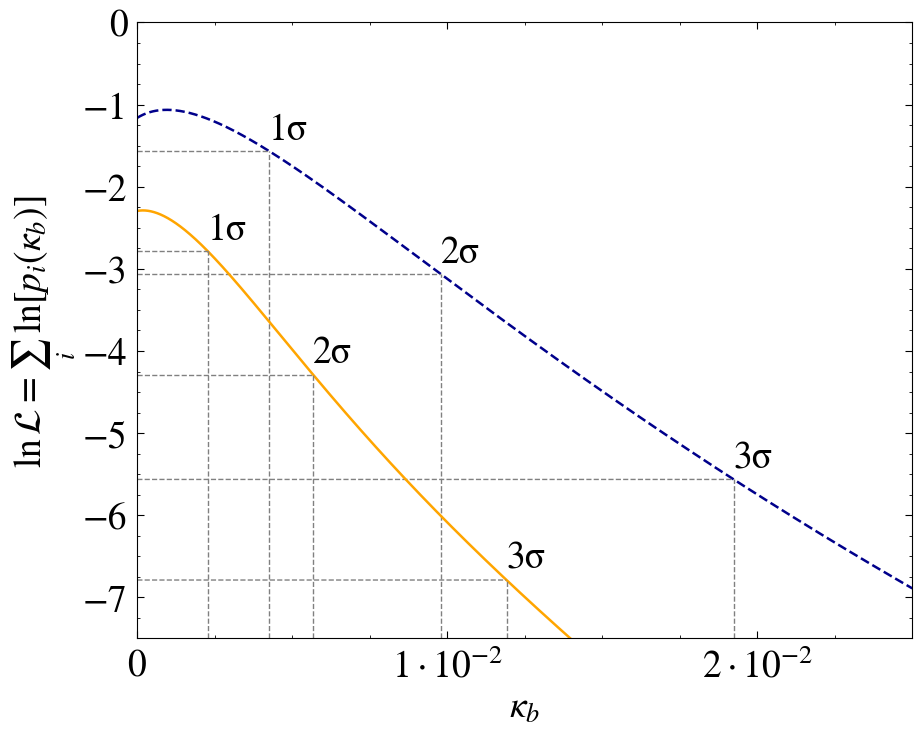

In [15]:
### LIKELIHOOD FUNCTION OPTIMISATION. OPTIMAL KAPPA D COMPUTATION
import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import scipy as sc
from math import log, e
import pylab


fontsize_value = 27
plt.rcParams.update({'font.size': fontsize_value})
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

fig, ax = plt.subplots(1,1, figsize = (10,8))

ax.set_xlabel(r'$\kappa_{b}$')
ax.set_ylabel('$\ln \mathcal{L} = \sum_i \ \ln [p_i (\kappa_{b})]$')
ax.set_xlim([0, 0.025])

ax.set_xticks([0, 0.01, 0.02])
xticks_list = ['$0$', '$1 \cdot 10^{-2}$', '$2 \cdot 10^{-2}$']
ax.set_xticklabels(xticks_list)
bot_lim = -7.5
top_lim = 0

ax.set_ylim(bottom = bot_lim, top = top_lim)
ax.tick_params(which = 'major', length = 5)
ax.tick_params(which = 'both', direction = 'in', top = True, right = True)
ax.tick_params(axis='both', which='both', pad=7)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

grayLineWidth = 1

#################     BEFORE PARITY UPDATE   #####################

def minus_likelihood(k_d, theta_dict, k_star_dict, d_inv_dict, reference_values = True):
    '''Computes the value of a negative likelihood function defined using p_i = 1/(1+(r/r_w)^2) * 2/(pi*r_w) probability density
    function. r = θ is the distance from the MaCL and r_w = (k_star + k_d)/d is the half width of the corrugated 
    microlensing band. Returns the value of the function.
    Arguments are the independent variable k_d and dictionaries for theta, k_star and d_inv.
    reference_values = True if we want to set k_star = mean(k_star_i) for the cases where we have no information
    about the value of k_star.'''
    
    L_total_value = 0
    # mean k_star    
    k_star_values = np.array([])
    for idx in k_star_dict:
        if k_star_dict[idx] != 'nan':
            k_star_values = np.append(k_star_values, k_star_dict[idx])    
    mean_k_star = np.mean(k_star_values)
   
    # Likelihood value computation
    for idx in theta_dict:
        theta = theta_dict[idx]
        k_star = k_star_dict[idx]
        d_inv = d_inv_dict[idx]
        
        if str(k_star) == 'nan' and reference_values == True:  
            k_star = mean_k_star      # for the cases without k_star information we use mean value of other clusters
        if str(d_inv) == 'nan':   # exclude cases without info of d_inv  (LS6)
            continue
        if str(theta) != 'nan' and str(d_inv) != 'nan':
            if k_d >= 0:
                
                r_w = (k_star + k_d) * d_inv
                theta_S = theta                       # DISTANCE FROM MaCL  (BEFORE PARITY UPDATE)
                P_i = 1/(1 + (theta_S/r_w)**2) * 1/(pi*r_w)    #PROBABILITY DENSITY FUNCTION
                
                L_value = - log(P_i)   # we define L_totatl = L_{neg} = - L  for minimizing, but we plot L > 0 
                L_total_value += L_value

            else:
                print('k_d = {} must be positive!'.format(k_d))
    return L_total_value


kappa_start = 0.5
k_d_bound = sc.optimize.Bounds(0, 1)

opt_result = sc.optimize.minimize(minus_likelihood, kappa_start, bounds= k_d_bound, 
                                  args=(theta_dict, k_star_dict, d_inv_dict, True))
opt_kappa_d = opt_result['x']
minimum_value = opt_result['fun']
print('\nBEFORE parity update:')
print('The optimal value for κb is:  {:.7f}'.format(opt_kappa_d[0]))

# For the positive likelihood function
maximum_likelihood_value = -minimum_value

N_values = 100001
X_values = np.linspace(0, 0.025, N_values)
Y_values = np.zeros(N_values)
for i in range(0, N_values):
    Y_values[i] = (-1) * minus_likelihood(X_values[i], theta_dict, k_star_dict, d_inv_dict, reference_values=True)
    
    
ax.plot(X_values, Y_values, linewidth = 1.8, color = 'darkblue', linestyle = 'dashed')


diff_array_0 = abs(Y_values - maximum_likelihood_value)
idx_0 = int(np.where(diff_array_0 == min(diff_array_0))[0][-1])


# ## 1 sigma 2 sigma and 3 sigma values for k_BH dashed lines

diff_array_1 = abs(Y_values - (maximum_likelihood_value - 0.5))
diff_array_2 = abs(Y_values - (maximum_likelihood_value - 2))  # locate where L = L0 - 2 for 2sigma error
diff_array_3 = abs(Y_values - (maximum_likelihood_value - 4.5))   # locate where L = L0 - 4.5 for 3sigma error

idx_1 = int(np.where(diff_array_1[idx_0:] == min(diff_array_1[idx_0:]))[0][-1]) + idx_0
idx_2 = int(np.where(diff_array_2[idx_0:] == min(diff_array_2[idx_0:]))[0][-1]) + idx_0
idx_3 = int(np.where(diff_array_3[idx_0:] == min(diff_array_3[idx_0:]))[0][-1]) + idx_0
kappa_b_1s = X_values[idx_1]
kappa_b_2s = X_values[idx_2]
kappa_b_3s = X_values[idx_3]

print('1σ κd value: {}'.format(kappa_b_1s))
print('2σ κd value: {}'.format(kappa_b_2s))
print('3σ κd value: {}'.format(kappa_b_3s))

ax.axvline(X_values[idx_1], 0, (Y_values[idx_1]-bot_lim)/(top_lim-bot_lim), linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.axvline(X_values[idx_2], 0, (Y_values[idx_2]-bot_lim)/(top_lim-bot_lim), linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.axvline(X_values[idx_3], 0, (Y_values[idx_3]-bot_lim)/(top_lim-bot_lim), linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.plot(np.arange(0, X_values[idx_1], 0.00001), np.arange(0, X_values[idx_1], 0.00001)*0 + Y_values[idx_1], linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.plot(np.arange(0, X_values[idx_2], 0.00001), np.arange(0, X_values[idx_2], 0.00001)*0 + Y_values[idx_2], linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.plot(np.arange(0, X_values[idx_3], 0.00001), np.arange(0, X_values[idx_3], 0.00001)*0 + Y_values[idx_3], linestyle = '--', color = 'grey', lw = grayLineWidth)
y_shift = 0.15
ax.text(X_values[idx_1], Y_values[idx_1] + y_shift, '1σ', fontdict={'size': fontsize_value})
ax.text(X_values[idx_2], Y_values[idx_2] + y_shift, '2σ', fontdict={'size': fontsize_value})
ax.text(X_values[idx_3], Y_values[idx_3] + y_shift, '3σ', fontdict={'size': fontsize_value})



#################     AFTER PARITY UPDATE   #####################

def minus_likelihood(k_d, theta_dict, k_star_dict, d_inv_dict, reference_values = True):
    '''Computes the value of a negative likelihood function defined using p_i = 1/(1+(r/r_w)^2) * 2/(pi*r_w) probability density
    function. r = θ is the distance from the MaCL and r_w = (k_star + k_d)/d is the half width of the corrugated 
    microlensing band. Returns the value of the function.
    Arguments are the independent variable k_d and dictionaries for theta, k_star and d_inv.
    reference_values = True if we want to set k_star = mean(k_star_i) for the cases where we have no information
    about the value of k_star.'''
    
    L_total_value = 0
    # mean k_star    
    k_star_values = np.array([])
    for idx in k_star_dict:
        if k_star_dict[idx] != 'nan':
            k_star_values = np.append(k_star_values, k_star_dict[idx])    
    mean_k_star = np.mean(k_star_values)
   
    # Likelihood value computation
    for idx in theta_dict:
        theta = theta_dict[idx]
        k_star = k_star_dict[idx]
        d_inv = d_inv_dict[idx]
        
        if str(k_star) == 'nan' and reference_values == True:  
            k_star = mean_k_star      # for the cases without k_star information we use mean value of other clusters
        if str(d_inv) == 'nan':   # exclude cases without info of d_inv
            continue
        if str(theta) != 'nan' and str(d_inv) != 'nan':
            if k_d >= 0:
                
                r_w = (k_star + k_d) * d_inv
                theta_S = theta + r_w                       # SEPARATION FROM SMOOTH CRITICAL LINE  (AFTER PARITY UPDATE)
                P_i = 1/(1 + (theta_S/r_w)**2) * 1/(pi*r_w)    #PROBABILITY DENSITY FUNCTION
                
                L_value = - log(P_i)   # we define L_totatl = L_{neg} = - L  for minimizing, but we plot L > 0 
                L_total_value += L_value

            else:
                print('k_d = {} must be positive!'.format(k_d))
    return L_total_value


kappa_start = 0.5
k_d_bound = sc.optimize.Bounds(0, 1)

opt_result = sc.optimize.minimize(minus_likelihood, kappa_start, bounds= k_d_bound, 
                                  args=(theta_dict, k_star_dict, d_inv_dict, True))
opt_kappa_d = opt_result['x']
minimum_value = opt_result['fun']
print('\nAFTER parity update:')
print('The optimal value for κb is:  {:.7f}'.format(opt_kappa_d[0]))

# For the positive likelihood function
maximum_likelihood_value = -minimum_value

N_values = 100001
X_values = np.linspace(0, 0.025, N_values)
Y_values = np.zeros(N_values)
for i in range(0, N_values):
    Y_values[i] = (-1) * minus_likelihood(X_values[i], theta_dict, k_star_dict, d_inv_dict, reference_values=True)
    
    
ax.plot(X_values, Y_values, linewidth = 1.8, color = 'orange')


diff_array_0 = abs(Y_values - maximum_likelihood_value)
idx_0 = int(np.where(diff_array_0 == min(diff_array_0))[0][-1])


# ## 1 sigma 2 sigma and 3 sigma values for k_BH dashed lines

diff_array_1 = abs(Y_values - (maximum_likelihood_value - 0.5))
diff_array_2 = abs(Y_values - (maximum_likelihood_value - 2))  # locate where L = L0 - 2 for 2sigma error
diff_array_3 = abs(Y_values - (maximum_likelihood_value - 4.5))   # locate where L = L0 - 4.5 for 3sigma error

idx_1 = int(np.where(diff_array_1[idx_0:] == min(diff_array_1[idx_0:]))[0][-1]) + idx_0
idx_2 = int(np.where(diff_array_2[idx_0:] == min(diff_array_2[idx_0:]))[0][-1]) + idx_0
idx_3 = int(np.where(diff_array_3[idx_0:] == min(diff_array_3[idx_0:]))[0][-1]) + idx_0
kappa_b_1s = X_values[idx_1]
kappa_b_2s = X_values[idx_2]
kappa_b_3s = X_values[idx_3]

print('1σ κd value: {}'.format(kappa_b_1s))
print('2σ κd value: {}'.format(kappa_b_2s))
print('3σ κd value: {}'.format(kappa_b_3s))

ax.axvline(X_values[idx_1], 0, (Y_values[idx_1]-bot_lim)/(top_lim-bot_lim), linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.axvline(X_values[idx_2], 0, (Y_values[idx_2]-bot_lim)/(top_lim-bot_lim), linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.axvline(X_values[idx_3], 0, (Y_values[idx_3]-bot_lim)/(top_lim-bot_lim), linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.plot(np.arange(0, X_values[idx_1], 0.00001), np.arange(0, X_values[idx_1], 0.00001)*0 + Y_values[idx_1], linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.plot(np.arange(0, X_values[idx_2], 0.00001), np.arange(0, X_values[idx_2], 0.00001)*0 + Y_values[idx_2], linestyle = '--', color = 'grey', lw = grayLineWidth)
ax.plot(np.arange(0, X_values[idx_3], 0.00001), np.arange(0, X_values[idx_3], 0.00001)*0 + Y_values[idx_3], linestyle = '--', color = 'grey', lw = grayLineWidth)
y_shift = 0.15
ax.text(X_values[idx_1], Y_values[idx_1] + y_shift, '1σ', fontdict={'size': fontsize_value})
ax.text(X_values[idx_2], Y_values[idx_2] + y_shift, '2σ', fontdict={'size': fontsize_value})
ax.text(X_values[idx_3], Y_values[idx_3] + y_shift, '3σ', fontdict={'size': fontsize_value})




plt.savefig('Figures/Figure 2 Likelihood function kb plot.png', bbox_inches = 'tight', dpi = 400)
plt.show()


# Final result for $\kappa_b$ and $\kappa_b^{3\sigma}$

In [7]:
# Mean κ0
parameters_dataframe = pd.read_csv('Numerical results/Magnification parameters table.dat', sep = '\t')
event_number_list = list(parameters_dataframe['i'])
k0_list = np.array([])
for event_number in event_number_list:
        idx = event_number_list.index(event_number)
        k0_i = parameters_dataframe['    κ_0    '][idx]
        k0_list = np.append(k0_list, k0_i)
mean_k_0 = np.mean(k0_list)


print('Optimal value for κb: κb = {:.5f}'.format(opt_kappa_d[0]))
print('3σ final value: κb (3σ) = {:5f}'.format(kappa_b_3s))
print('Mean value of the convergence at the positions of the images: κ0 = {:.3f}'.format(mean_k_0))
print('\nWhich corresponds to an upper limit (3σ) of {:.3f} % of the total mean convergence.'.format(kappa_b_3s/mean_k_0 * 100))

Optimal value for κb: κb = 0.00018
3σ final value: κb (3σ) = 0.011910
Mean value of the convergence at the positions of the images: κ0 = 0.691

Which corresponds to an upper limit (3σ) of 1.724 % of the total mean convergence.


In [ ]:


º

In [23]:
x


IndexError: arrays used as indices must be of integer (or boolean) type

In [23]:
x


IndexError: arrays used as indices must be of integer (or boolean) type

### Likelihood at $k_b = 0$

In [49]:
theta_dict[6] = 'nan'

In [56]:

summation = 0
summation_test = 0
for k in range(1, len(k_star_dict)+1):
    k_star = k_star_dict[k]
    d_inv = d_inv_dict[k]
    
    if d_inv != 'nan':
        if k_star =='nan':
            k_star = mean_kappa_star
        r_w = k_star * d_inv
    
    theta = theta_dict[k]
    if theta != 'nan':
        s = theta
        summation_test += np.abs(s)
        p_i = 1/(np.pi * r_w) * 1/(1 + (s/r_w)**2)
#         print(s, r_w, p_i, np.log(p_i))
        summation += np.log(p_i)
        
        

print('Likelihood')
print(summation)  
print('Sum of distances')
print(summation_test)

Likelihood
-1.160811066369848
Sum of distances
1.4264999999999999


In [64]:
r_w_dict_new = {}
theta_dict_new = {}
summation = 0
summation_test = 0
for k in range(1, len(k_star_dict)+1):
    k_star = k_star_dict[k]
    d_inv = d_inv_dict[k]
    
    if d_inv != 'nan':
        if k_star =='nan':
            k_star = mean_kappa_star
        r_w = k_star * d_inv
    theta = theta_dict[k]
    if theta != 'nan':
        r_w_dict_new[k] = r_w
        theta_dict_new[k] = theta
        s = theta + r_w
        summation_test += np.abs(s)
        p_i = 1/(np.pi * r_w) * 1/(1 + (s/r_w)**2)
#         print(s, r_w, p_i, np.log(p_i))
        summation += np.log(p_i)
        
        

print('Likelihood')
print(summation)  
print('Sum of distances')
print(summation_test)


Likelihood
-2.2947261196061457
Sum of distances
1.6687919055677891


In [84]:
np.array(list(r_w_dict_new.values()))

array([0.09970974, 0.17480813, 0.14481909, 0.08110609, 0.19490784,
       0.20359711, 0.15868089, 0.03294427, 0.10501368])

In [85]:
r_w_values = np.array(list(r_w_dict_new.values()))

In [89]:
theta_dict_values = np.array(list(theta_dict_new.values()))

In [92]:
np.sum(np.abs(theta_dict_values))

1.4264999999999999

In [93]:
np.sum(np.abs(theta_dict_values + r_w_values))

1.6687919055677891

In [94]:
np.sum(theta_dict_values)

-1.0315

In [95]:
np.sum(-r_w_values)

-1.1955868422344904